In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [50]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
lattice_vectors = loadlattice("./wannier.out")
EsUp, _ = wannier_bands(HwannierUp, cell_mapUp, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));
EsDn, _ = wannier_bands(HwannierDn, cell_mapDn, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));

In [5]:
np.savetxt("EsUp.txt", EsUp)
np.savetxt("EsDn.txt", EsDn)

In [13]:
EnergiesUp, DOSUp = density_of_states(HwannierUp, cell_mapUp, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=100);
EnergiesDn, DOSDn = density_of_states(HwannierDn, cell_mapDn, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=100);

In [12]:
#np.savetxt("DosUp.txt", hcat(EnergiesUp, DOSUp))
#np.savetxt("DosDn.txt", hcat(EnergiesDn, DOSDn))

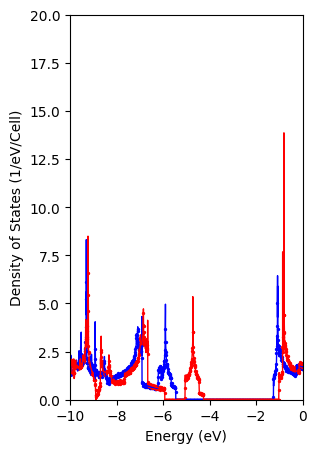

(0.0, 20.0)

In [33]:
figure(figsize=(3, 5))
scatter(EnergiesUp, DOSUp, s=2, color="blue")
scatter(EnergiesDn, DOSDn, s=2, color="red")

density_of_states("../DOS/BN22NC.dosUp", "../DOS/BN22NC.dosDn", linewidth=1, color_up="blue", color_dn="red")
xlim(-10, 0)
ylim(0, 20)

In [36]:
x, y = find_chemical_potential(EnergiesDn, DOSDn)
x[argmin(abs.(y .- 15.5))]

-4.713046407040281

In [81]:
epsilons = zeros(100, 100);
kpoints = bandstructkpoints2q(interpolate=5);
energies = collect(range(0, 100, length=10000));
landau_lower = zeros(100);
landau_upper = zeros(100);

In [82]:
for (i, k) in enumerate(kpoints[1:100])
    #println(i); flush(stdout)
    i == 1 && continue
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    for (j, ω) in enumerate(range(0.05, 1.5, length=100))
        epsilons[i, j] = imag(1/ ϵ(k, lattice_vectors, ω, energies, polarizations, δ=0.001, normalized=true))
    end
    lower = findfirst(iszero.(polarizations))
    upper = findfirst(.!iszero.(polarizations)[lower:end])+lower-1
    landau_lower[i] = energies[lower]
    landau_upper[i] = energies[upper]
end

In [83]:
plasmon = [range(0.05, 1.5, length=100)[argmax(x)] for x in eachrow(log.(abs.(epsilons[2:50, :])))];
plasmon = [0, plasmon...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon)
confinements[1] = 0;
plasmon = smooth(plasmon, win_len=10)
confinements = smooth(confinements, win_len=10);
#landau_lower = smooth(landau_lower, win_len=10);
#landau_upper = smooth(landau_upper, win_len=10);

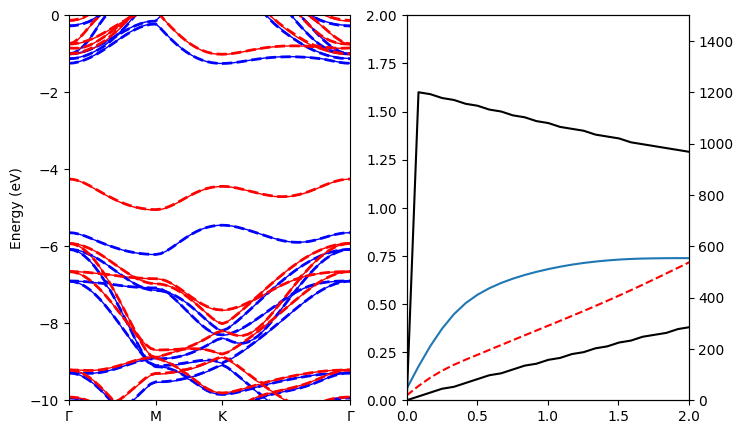

In [77]:
figure(figsize=(8, 5))
subplot(1, 2, 1)
plot_bands("../BN22NC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
plot_bands(HwannierUp, cell_mapUp, kpointsfile="../bandstruct.kpoints", linewidth=2, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cell_mapDn, kpointsfile="../bandstruct.kpoints", linewidth=2, color="red", linestyle="dashed")
xlim(0, 55)
ylim(-10, 0/eV)
xlabel("")
subplot(1, 2, 2)

plot(qs*10, plasmon)
plot(qs*10, landau_lower[1:50], color="black")
plot(qs*10, landau_upper[1:50], color="black")

ylim(0, 2)
twinx()
plot(qs*10, confinements, color="red", linestyle="dashed")
ylim(0, 1500)
xlabel("q (nm⁻¹)")
xlim(0, maximum(qs)*10)
xlim(0, 2)
savefig("BN22NC-Plasmon.pdf")

In [71]:
np.savetxt("Plasmon.txt", hcat(qs, plasmon, confinements))

In [85]:
qs_txt, plasmon_txt, confinements_txt = [x for x in eachcol(np.loadtxt("Plasmon.txt"))];

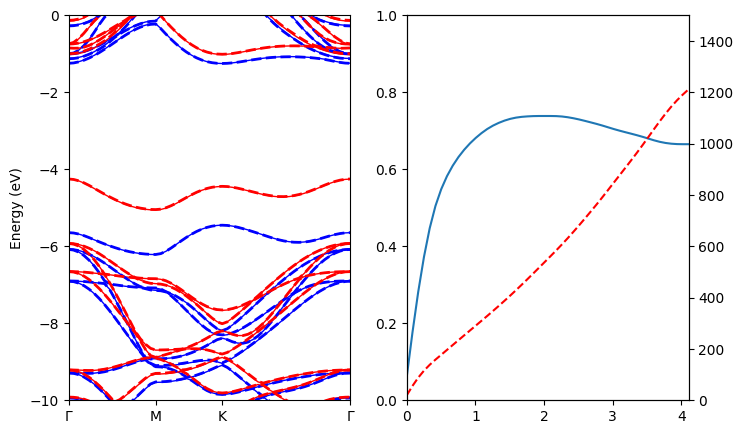

In [88]:
figure(figsize=(8, 5))
subplot(1, 2, 1)
plot_bands("../BN22NC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
plot_bands(HwannierUp, cell_mapUp, kpointsfile="../bandstruct.kpoints", linewidth=2, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cell_mapDn, kpointsfile="../bandstruct.kpoints", linewidth=2, color="red", linestyle="dashed")
xlim(0, 55)
ylim(-10, 0/eV)
xlabel("")
subplot(1, 2, 2)

plot(qs_txt*10, plasmon_txt)
ylim(0, 1)
twinx()
plot(qs_txt*10, confinements_txt, color="red", linestyle="dashed")
ylim(0, 1500)
xlabel("q (nm⁻¹)")
xlim(0, maximum(qs)*10)
savefig("BN22NC-Plasmon.pdf")